# =========================================
# TP Integrador de Procesamiento de Lenguaje Natural
## Universidad de Palermo
###Grupo 1

---

**Clasificación y Recomendación de artículos científicos**

Profesor:
-  MUÑOZ, VICTOR EZEQUIEL

Integrantes:
-  CHOLAKIAN, ANDRES GUSTAVO
-  GRECCO, GONZALO DANIEL
-  MILLE, NICOLAS
-  RUBIÑO MONTILLA, SIMON MARTIN
# =========================================

##1. Configuración inicial y detección de hardware

In [ ]:
# 1.1 Detección automática de GPU/CPU
import torch
import platform
import psutil

print("=" * 50)
print("CONFIGURACIÓN DEL ENTORNO")
print("=" * 50)

# Detectar dispositivo para modelos que usan GPU (SciBERT, redes neuronales)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print(f"   GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   No se detectó GPU.")

# Información de CPU
print(f"   CPU: {platform.processor()}")
print(f"   Núcleos físicos: {psutil.cpu_count(logical=False)}")
print(f"   RAM total: {psutil.virtual_memory().total / 1e9:.1f} GB")

CONFIGURACIÓN DEL ENTORNO
   GPU detectada: Tesla T4
   VRAM disponible: 15.6 GB
   CPU: x86_64
   Núcleos físicos: 1
   RAM total: 13.6 GB


In [ ]:
!pip install --upgrade pip
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn nltk spacy
!pip install torch transformers accelerate
!pip install wordcloud scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


##2. Descarga del dataset (arXiv desde Kaggle)

In [ ]:
# 2.1 Descarga usando kagglehub
import kagglehub
import os
import shutil

download_path = kagglehub.dataset_download("Cornell-University/arxiv")
print(f"Dataset descargado en: {download_path}")

# 2.2 Ver archivos descargados
files = os.listdir(download_path)
print(f"Archivos encontrados: {files}")

# 2.3 Identificar el archivo principal
arxiv_file = None
for f in files:
      arxiv_file = os.path.join(download_path, f)
      break

if arxiv_file:
    print(f"Archivo a procesar: {arxiv_file}")
else:
    print("No se encontró archivo con extensión esperada. Verificar.")

Using Colab cache for faster access to the 'arxiv' dataset.
Dataset descargado en: /kaggle/input/arxiv
Archivos encontrados: ['arxiv-metadata-oai-snapshot.json']
Archivo a procesar: /kaggle/input/arxiv/arxiv-metadata-oai-snapshot.json


##3. Carga y exploración inicial del dataset

In [ ]:
import pandas as pd
import json

# 3.1 Cargar el dataset
def load_arxiv_dataset(filepath, nrows=None):
    """
    Carga el dataset de arXiv.
    nrows: cantidad de filas a cargar (None = todas)
    """
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if nrows and i >= nrows:
                break
            try:
                data.append(json.loads(line))
            except:
                continue

    df = pd.DataFrame(data)
    return df

# Para el desarrollo final, usar nrows=None o un número grande
print("Cargando dataset (muestra de 150000 papers para pruebas)")
df = load_arxiv_dataset(arxiv_file, nrows=150000)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

# 3.2 Ver columnas disponibles
print("\nColumnas del dataset:")
print(df.columns.tolist())

# 3.3 Vista previa
print("\nVista previa (primeras 2 filas):")
print(df.head(2))

# 3.4 Información general
print("\nInformación del dataset:")
print(df.info())

Cargando dataset (muestra de 150000 papers para pruebas)
Dataset cargado: 150000 filas, 14 columnas

Columnas del dataset:
['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed']

Vista previa (primeras 2 filas):
          id       submitter  \
0  0704.0001  Pavel Nadolsky   
1  0704.0002    Louis Theran   

                                             authors  \
0  C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...   
1                    Ileana Streinu and Louis Theran   

                                               title  \
0  Calculation of prompt diphoton production cros...   
1           Sparsity-certifying Graph Decompositions   

                                  comments               journal-ref  \
0  37 pages, 15 figures; published version  Phys.Rev.D76:013009,2007   
1    To appear in Graphs and Combinatorics                      None   

                      

##4. Preprocesamiento de texto (optimizado para CPU)

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Descargar recursos de NLTK
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

# Configurar stopwords en inglés (idioma de arXiv)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Limpia y normaliza texto para procesamiento.
    Esta función corre en CPU (óptimo)
    """
    if not isinstance(text, str):
        return ""

    # Convertir a minúsculas
    text = text.lower()

    # Eliminar caracteres especiales, mantener letras, números y espacios
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenizar y aplicar lematización
    # tokens = nltk.word_tokenize(text)
    # tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    # text = ' '.join(tokens)

    return text

# 4.1 Aplicar preprocesamiento
print("Preprocesando textos (CPU)...")

title_col = 'title'
abstract_col = 'abstract'

if title_col and abstract_col:
    df['clean_title'] = df[title_col].apply(clean_text)
    df['clean_abstract'] = df[abstract_col].apply(clean_text)
    df['text'] = df['clean_title'] + " " + df['clean_abstract']
    print(f"Texto combinado creado: 'title' + 'abstract'")
else:
    print("No se encontraron columnas 'title' y 'abstract'")
    print(f"Columnas disponibles: {df.columns.tolist()}")

Preprocesando textos (CPU)...
Texto combinado creado: 'title' + 'abstract'


##5. Definición de labels (macro-categorías de arXiv)

In [ ]:
# 5.1 Taxonomía de macro-categorías según arXiv
# Fuente: https://arxiv.org/category_taxonomy

MACRO_CATEGORIES = {
    'cs': 'Computer Science',
    'math': 'Mathematics',
    'stat': 'Statistics',
    'physics': 'Physics',
    'astro-ph': 'Astrophysics',
    'q-bio': 'Quantitative Biology',
    'q-fin': 'Quantitative Finance',
    'eess': 'Electrical Engineering',
    'econ': 'Economics'
}

def get_primary_category(categories_str):
    """
    Extrae la categoría primaria (primera de la lista)
    Ejemplo: 'cs.CL cs.LG' -> 'cs'
    """
    if not isinstance(categories_str, str):
        return None

    # Tomar la primera categoría
    first_cat = categories_str.split()[0] if categories_str.split() else None

    if first_cat:
        # Extraer el prefijo (ej: 'cs.CL' -> 'cs')
        prefix = first_cat.split('.')[0]
        return prefix
    return None

def map_to_macro_category(prefix):
    """Mapea el prefijo a macro-categoría"""
    return MACRO_CATEGORIES.get(prefix, 'Other')

# 5.2 Aplicar extracción de categorías
# Buscar la columna de categorías
cat_col = None
for col in df.columns:
    if 'categories' in col.lower():
        cat_col = col
        break

if cat_col:
    df['primary_prefix'] = df[cat_col].apply(get_primary_category)
    df['macro_category'] = df['primary_prefix'].apply(map_to_macro_category)

    # Filtrar 'Other' para usar solo las macro-categorías definidas
    df_filtered = df[df['macro_category'] != 'Other'].copy()
    print(f"Categorías asignadas: {df_filtered['macro_category'].nunique()} macro-categorías")
    print(f"   Distribución:\n{df_filtered['macro_category'].value_counts()}")
else:
    print("No se encontró columna de categorías")
    df_filtered = df.copy()

# 5.3 Balanceo de clases (submuestreo)
from sklearn.utils import resample

def balance_dataset(df, category_col='macro_category', samples_per_class=750):
    """
    Balancea el dataset tomando 'samples_per_class' muestras por categoría
    """
    balanced_dfs = []
    min_samples = samples_per_class

    for cat in df[category_col].unique():
        df_cat = df[df[category_col] == cat]
        n_samples = min(len(df_cat), min_samples)
        df_balanced = resample(df_cat, replace=False, n_samples=n_samples, random_state=42)
        balanced_dfs.append(df_balanced)

    return pd.concat(balanced_dfs, ignore_index=True)

# Aplicar balanceo
# Para pruebas: 200, para entrenamiento final: 1000-2000
df_balanced = balance_dataset(df_filtered, samples_per_class=750)
print(f"\nDataset balanceado: {df_balanced.shape[0]} filas")
print(df_balanced['macro_category'].value_counts())

Categorías asignadas: 7 macro-categorías
   Distribución:
macro_category
Mathematics             31466
Astrophysics            26433
Physics                  9943
Computer Science         8583
Quantitative Biology     1800
Statistics               1106
Quantitative Finance      748
Name: count, dtype: int64

Dataset balanceado: 5248 filas
macro_category
Mathematics             750
Physics                 750
Astrophysics            750
Quantitative Biology    750
Computer Science        750
Statistics              750
Quantitative Finance    748
Name: count, dtype: int64


##6. Clasificación con TF-IDF + Modelos clásicos (CPU)

 Split de datos:
   Train: 4198 muestras
   Test: 1050 muestras

 Vectorizando con TF-IDF...
 Matriz TF-IDF: (4198, 10000)

 Entrenando modelos...
   Logistic Regression...
      Accuracy: 0.8486
   Naive Bayes...
      Accuracy: 0.8505
   Linear SVM...
      Accuracy: 0.8571

 Mejor modelo: Linear SVM con accuracy 0.8571


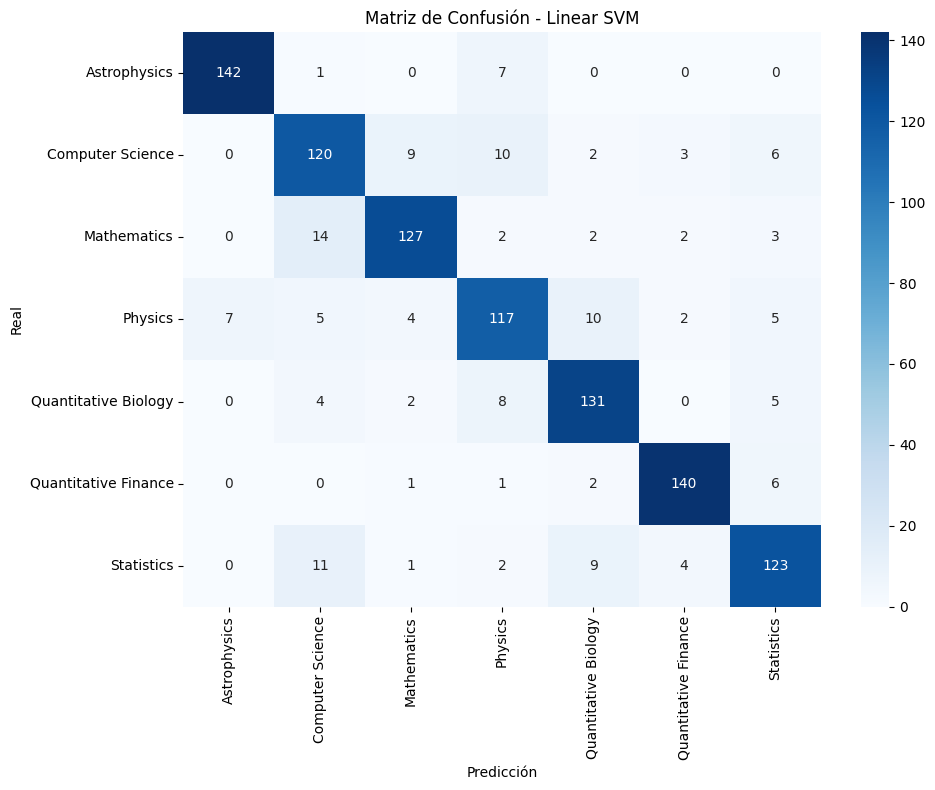

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Preparar datos
X = df_balanced['text'].values
y = df_balanced['macro_category'].values

# Codificar etiquetas a números
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f" Split de datos:")
print(f"   Train: {len(X_train)} muestras")
print(f"   Test: {len(X_test)} muestras")

# 6.2 Vectorización TF-IDF (en CPU)
print("\n Vectorizando con TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f" Matriz TF-IDF: {X_train_tfidf.shape}")

# 6.3 Entrenar y evaluar modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(random_state=42, max_iter=2000)
}

results = {}

print("\n Entrenando modelos...")
for name, model in models.items():
    print(f"   {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': acc,
        'predictions': y_pred,
        'report': classification_report(y_test, y_pred, target_names=label_encoder.classes_)
    }
    print(f"      Accuracy: {acc:.4f}")

# 6.4 Mostrar mejores resultados
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n Mejor modelo: {best_model_name} con accuracy {results[best_model_name]['accuracy']:.4f}")

# 6.5 Matriz de confusión del mejor modelo
y_pred_best = results[best_model_name]['predictions']
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

##7. Generación de embeddings con SciBERT (GPU)

In [ ]:
from transformers import AutoTokenizer, AutoModel
import numpy as np
from tqdm import tqdm

# 7.1 Configurar GPU para SciBERT
print(" Cargando SciBERT...")
print(f"   Dispositivo: {device}")

tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")
model = AutoModel.from_pretrained("allenai/scibert_scivocab_uncased").to(device)
model.eval()

print(" SciBERT cargado")

# 7.2 Función para generar embeddings batch por batch
def generate_scibert_embeddings(texts, batch_size=16, max_length=512):
    """
    Genera embeddings usando SciBERT.
    Optimizado para GPU: procesa en batches.
    """
    embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Generando embeddings"):
            batch_texts = texts[i:i+batch_size]

            # Tokenizar
            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            )

            # Mover a GPU
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # Forward pass
            outputs = model(**inputs)

            # Usar el token [CLS] como embedding del documento
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

# 7.3 Generar embeddings
n_scibert_samples = len(df_balanced)
df_scibert = df_balanced.head(n_scibert_samples).copy()

print(f"\n Generando embeddings con SciBERT para {n_scibert_samples} documentos...")

# Limpiar textos (cortos para evitar tokens excesivos)
texts_for_scibert = df_scibert['text'].str[:1000].tolist()
scibert_embeddings = generate_scibert_embeddings(texts_for_scibert, batch_size=8)

print(f" Embeddings generados: {scibert_embeddings.shape}")

# 7.4 Clasificación con embeddings SciBERT (red simple)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Preparar datos para SciBERT
y_scibert = df_scibert['macro_category'].values
y_scibert_encoded = label_encoder.transform(y_scibert)

# Split
X_train_sci, X_test_sci, y_train_sci, y_test_sci = train_test_split(
    scibert_embeddings, y_scibert_encoded, test_size=0.2, random_state=42, stratify=y_scibert_encoded
)

# Clasificador simple sobre embeddings
clf_scibert = LogisticRegression(max_iter=1000, random_state=42)
clf_scibert.fit(X_train_sci, y_train_sci)
y_pred_sci = clf_scibert.predict(X_test_sci)
acc_scibert = accuracy_score(y_test_sci, y_pred_sci)

print(f"\n Resultado clasificación con SciBERT + LogisticRegression:")
print(f"   Accuracy: {acc_scibert:.4f}")
print(f"   (TF-IDF + {best_model_name}: {results[best_model_name]['accuracy']:.4f})")

 Cargando SciBERT...
   Dispositivo: cuda


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/228k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 SciBERT cargado

 Generando embeddings con SciBERT para 5248 documentos...


Generando embeddings: 100%|██████████| 656/656 [00:53<00:00, 12.34it/s]


 Embeddings generados: (5248, 768)

 Resultado clasificación con SciBERT + LogisticRegression:
   Accuracy: 0.8429
   (TF-IDF + Linear SVM: 0.8571)


### 7.5 Clasificación con embeddings SciBERT + Linear SVM (temporal)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

print("\nClasificación con SciBERT + Linear SVM (temporal):")
# Clasificador Linear SVM sobre embeddings SciBERT
clf_scibert_svm = LinearSVC(random_state=42, max_iter=2000) # Variable temporal
clf_scibert_svm.fit(X_train_sci, y_train_sci)
y_pred_sci_svm = clf_scibert_svm.predict(X_test_sci)
acc_scibert_svm = accuracy_score(y_test_sci, y_pred_sci_svm)

print(f"   Accuracy (SciBERT + Linear SVM): {acc_scibert_svm:.4f}")
print("\nInforme de Clasificación (SciBERT + Linear SVM):\n")
print(classification_report(y_test_sci, y_pred_sci_svm, target_names=label_encoder.classes_))


Clasificación con SciBERT + Linear SVM (temporal):
   Accuracy (SciBERT + Linear SVM): 0.7981

Informe de Clasificación (SciBERT + Linear SVM):

                      precision    recall  f1-score   support

        Astrophysics       0.90      0.93      0.92       150
    Computer Science       0.72      0.68      0.70       150
         Mathematics       0.88      0.85      0.86       150
             Physics       0.68      0.67      0.68       150
Quantitative Biology       0.77      0.83      0.80       150
Quantitative Finance       0.90      0.87      0.89       150
          Statistics       0.72      0.75      0.73       150

            accuracy                           0.80      1050
           macro avg       0.80      0.80      0.80      1050
        weighted avg       0.80      0.80      0.80      1050



##8. Sistema de recomendación por similitud coseno

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def build_recommendation_system(embeddings, metadata_df, k=10):
    """
    Construye un sistema de recomendación basado en similitud coseno.
    embeddings: matriz de embeddings (documentos x features)
    metadata_df: DataFrame con información de los documentos
    k: número de recomendaciones por defecto
    """
    # Calcular matriz de similitud
    print(" Calculando matriz de similitud coseno...")
    similarity_matrix = cosine_similarity(embeddings)
    print(f" Matriz de similitud: {similarity_matrix.shape}")

    def recommend(doc_idx, k=k):
        """Recomienda documentos similares a doc_idx"""
        sim_scores = list(enumerate(similarity_matrix[doc_idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        # Excluir el propio documento
        sim_scores = sim_scores[1:k+1]
        indices = [i[0] for i in sim_scores]
        scores = [i[1] for i in sim_scores]
        return indices, scores

    return recommend, similarity_matrix

# 8.1 Construir sistema con TF-IDF
print("\n" + "="*50)
print("SISTEMA DE RECOMENDACIÓN CON TF-IDF")
print("="*50)

recommend_tfidf, sim_matrix_tfidf = build_recommendation_system(
    X_train_tfidf.toarray()[:1000],
    df_balanced.head(1000)
)

# 8.2 Construir sistema con SciBERT
print("\n" + "="*50)
print("SISTEMA DE RECOMENDACIÓN CON SCIBERT")
print("="*50)

recommend_scibert, sim_matrix_scibert = build_recommendation_system(
    scibert_embeddings,
    df_scibert
)


SISTEMA DE RECOMENDACIÓN CON TF-IDF
 Calculando matriz de similitud coseno...
 Matriz de similitud: (1000, 1000)

SISTEMA DE RECOMENDACIÓN CON SCIBERT
 Calculando matriz de similitud coseno...
 Matriz de similitud: (5248, 5248)


##9. Evaluación del sistema de recomendación (métricas multicriterio)

In [ ]:
def relevance_multicriteria(recommended_paper, query_paper, metadata_df, weights=None):
    """
    Calcula relevancia según múltiples criterios.

    Criterios:
    1. Misma categoría principal (peso 1.0 por defecto)
    2. Misma macro-categoría (peso 0.5)
    3. Coautoría (peso 0.3)
    4. Superposición de vocabulario técnico (peso 0.2)
    """
    if weights is None:
        weights = {'same_primary': 1.0, 'same_macro': 0.5, 'coauthor': 0.3, 'vocab_overlap': 0.2}

    score = 0.0

    # Criterio 1: Misma categoría principal
    if query_paper.get('primary_prefix') == recommended_paper.get('primary_prefix'):
        score += weights['same_primary']

    # Criterio 2: Misma macro-categoría
    if query_paper.get('macro_category') == recommended_paper.get('macro_category'):
        score += weights['same_macro']

    # Criterio 3: Coautoría (si existen columnas de autores)
    if 'authors' in metadata_df.columns:
        query_authors = set(str(query_paper.get('authors', '')).split(','))
        rec_authors = set(str(recommended_paper.get('authors', '')).split(','))
        if len(query_authors & rec_authors) > 0:
            score += weights['coauthor']

    # Criterio 4: Superposición de vocabulario (simplificado)
    score = min(score, 1.0)  # Normalizar a 0-1
    return score

def evaluate_recommendation_system(recommend_func, metadata_df, embeddings, k=10, test_indices=None):
    """
    Evalúa el sistema de recomendación con métricas estándar.
    """
    if test_indices is None:
        test_indices = list(range(min(100, len(embeddings))))

    precision_at_k = []
    recall_at_k = []

    for idx in test_indices:
        query_paper = metadata_df.iloc[idx].to_dict()
        rec_indices, _ = recommend_func(idx, k=k)

        # Calcular relevancia de cada recomendación
        relevant = 0
        for rec_idx in rec_indices:
            rec_paper = metadata_df.iloc[rec_idx].to_dict()
            relevance_score = relevance_multicriteria(rec_paper, query_paper, metadata_df)
            if relevance_score > 0.5:  # Umbral de relevancia
                relevant += 1

        # Precision@k
        p_at_k = relevant / len(rec_indices) if rec_indices else 0
        precision_at_k.append(p_at_k)

        # Recall@k
        recall_at_k.append(relevant / min(5, len(rec_indices)) if rec_indices else 0)

    return {
        'precision@k': np.mean(precision_at_k),
        'recall@k': np.mean(recall_at_k)
    }

# 9.1 Evaluar TF-IDF
print("\nEvaluando sistema TF-IDF...")
eval_tfidf = evaluate_recommendation_system(
    recommend_tfidf,
    df_balanced.head(1000),
    X_train_tfidf.toarray()[:1000],
    k=5
)
print(f"   Precision@5: {eval_tfidf['precision@k']:.4f}")
print(f"   Recall@5: {eval_tfidf['recall@k']:.4f}")

# 9.2 Evaluar SciBERT
print("\n Evaluando sistema SciBERT...")
eval_scibert = evaluate_recommendation_system(
    recommend_scibert,
    df_scibert,
    scibert_embeddings,
    k=5
)
print(f"   Precision@5: {eval_scibert['precision@k']:.4f}")
print(f"   Recall@5: {eval_scibert['recall@k']:.4f}")

# 9.3 Comparativa final
print("\n" + "="*50)
print("COMPARATIVA FINAL - MEJORES RESULTADOS")
print("="*50)
print(f"{'Modelo':<20} {'Accuracy':<12} {'Precision@5':<12} {'Recall@5':<12}")
print("-"*56)
print(f"{'TF-IDF + ' + best_model_name:<20} {results[best_model_name]['accuracy']:.4f}       {eval_tfidf['precision@k']:.4f}        {eval_tfidf['recall@k']:.4f}")
print(f"{'SciBERT + LR':<20} {acc_scibert:.4f}       {eval_scibert['precision@k']:.4f}        {eval_scibert['recall@k']:.4f}")


Evaluando sistema TF-IDF...
   Precision@5: 0.7360
   Recall@5: 0.7360

 Evaluando sistema SciBERT...
   Precision@5: 0.8340
   Recall@5: 0.8340

COMPARATIVA FINAL - MEJORES RESULTADOS
Modelo               Accuracy     Precision@5  Recall@5    
--------------------------------------------------------
TF-IDF + Linear SVM  0.8571       0.7360        0.7360
SciBERT + LR         0.8429       0.8340        0.8340


##10. Visualizaciones y ejemplos cualitativos


EJEMPLOS POR MACRO-CATEGORÍA

📋 Categorías encontradas en dataset TF-IDF: ['Mathematics', 'Physics']
   - Mathematics: índice 0
   - Physics: índice 750

📋 Categorías encontradas en dataset SciBERT: ['Mathematics', 'Physics', 'Astrophysics', 'Quantitative Biology', 'Computer Science', 'Quantitative Finance', 'Statistics']

COMPARATIVA DE RECOMENDACIONES: TF-IDF vs SciBERT

############################################################
# CATEGORÍA: Mathematics
############################################################

RECOMENDACIONES CON TF-IDF - Categoría: Mathematics

📄 PAPER CONSULTADO:
   Título: Stable theories and representation over sets
   Macro-categoría: Mathematics
   Categoría primaria: math

📚 TOP 5 RECOMENDACIONES:
   #   Similitud  Categoría          Título
   ------------------------------------------------------------
   1   0.2017     Mathematics        Involutions on 3-Manifolds and Self-dual, Binary Codes
   2   0.1906     Mathematics        Two body systems from s

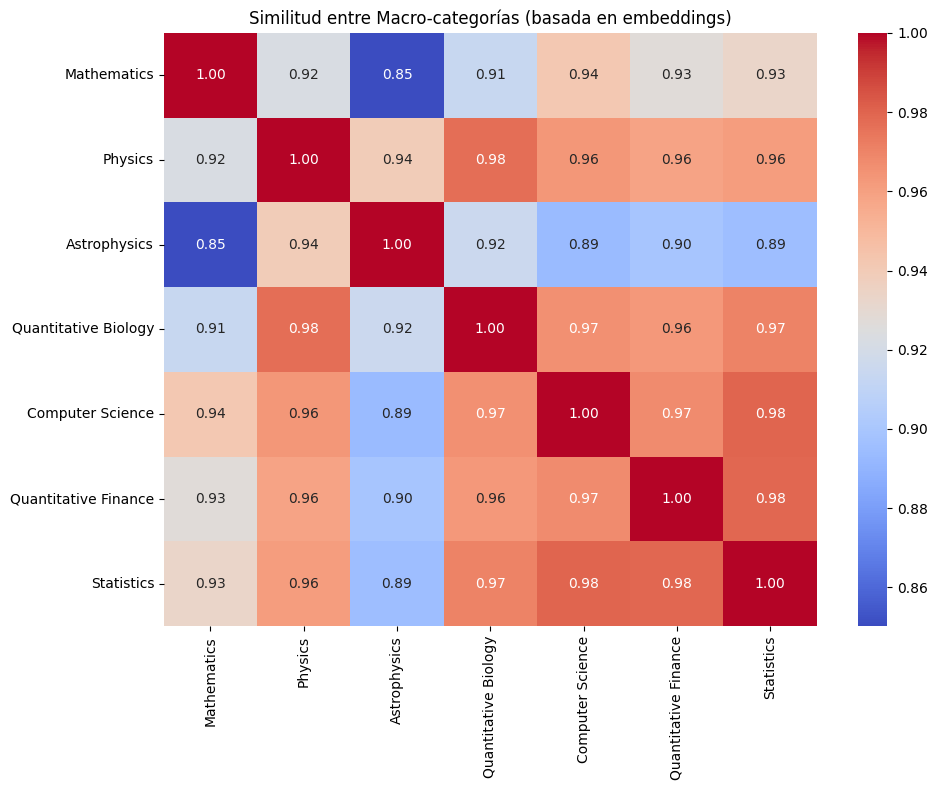


📊 Visualización t-SNE de embeddings SciBERT:
🔄 Calculando t-SNE (puede tomar ~30 segundos)...


/tmp/ipykernel_12996/512239033.py:192: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10', len(unique_cats))


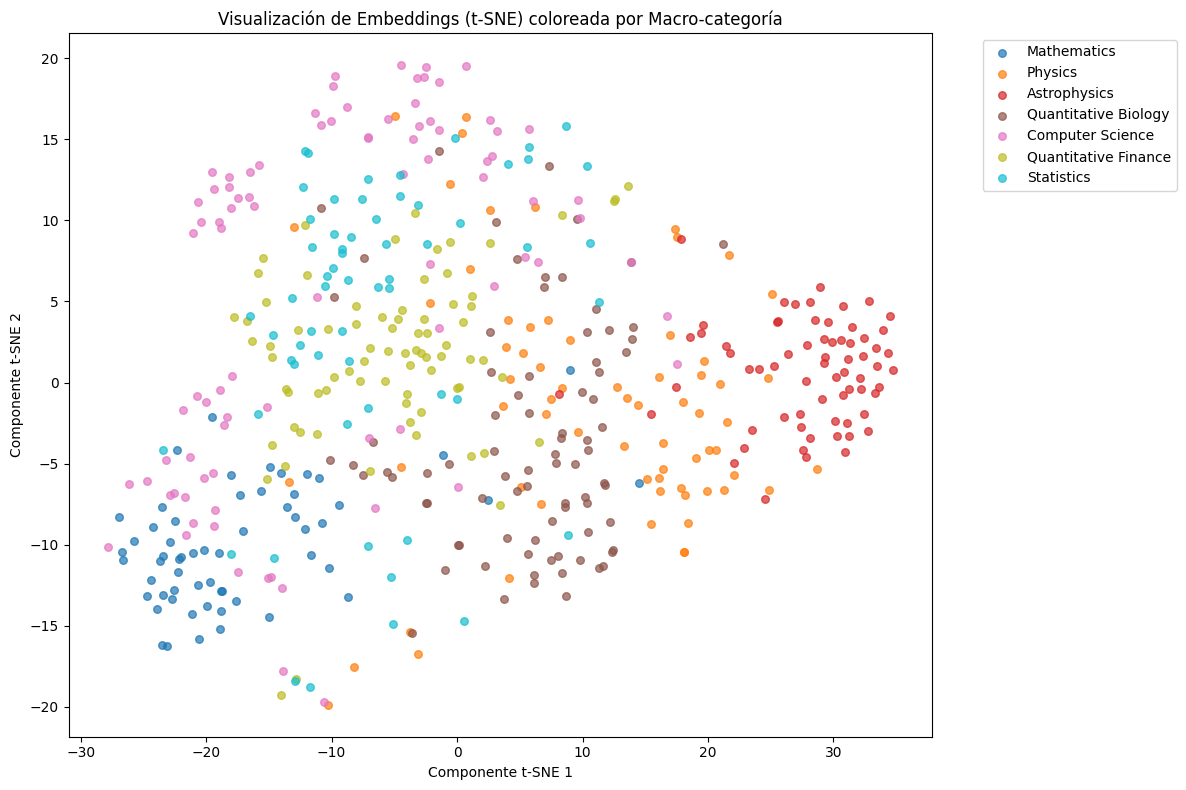


TABLA RESUMEN - VALORACIÓN CUALITATIVA DE RECOMENDACIONES

🔍 Evaluación TF-IDF:

📊 TF-IDF
  Categoría Mismas (exactas) Precisión@5
Mathematics              3/5         60%
    Physics              1/5         20%

🔍 Evaluación SciBERT:

📊 SciBERT
           Categoría Mismas (exactas) Precisión@5
         Mathematics              3/5         60%
             Physics              5/5        100%
        Astrophysics              5/5        100%
Quantitative Biology              1/5         20%
    Computer Science              5/5        100%
Quantitative Finance              5/5        100%
          Statistics              2/5         40%


In [ ]:
# ====================================================
# 10. VISUALIZACIONES Y EJEMPLOS CUALITATIVOS
# ====================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 10.1 Función para mostrar ejemplos
def show_recommendation_example(recommend_func, metadata_df, idx, k=5, title="Recomendaciones"):
    """
    Muestra un ejemplo de recomendación.

    Parámetros:
    - recommend_func: función de recomendación (de TF-IDF o SciBERT)
    - metadata_df: DataFrame con metadatos
    - idx: índice del paper consultado
    - k: número de recomendaciones
    - title: título a mostrar
    """
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")

    # Paper consultado
    print(f"\n📄 PAPER CONSULTADO:")
    print(f"   Título: {metadata_df.iloc[idx].get('title', 'N/A')[:120]}")
    print(f"   Macro-categoría: {metadata_df.iloc[idx].get('macro_category', 'N/A')}")
    print(f"   Categoría primaria: {metadata_df.iloc[idx].get('primary_prefix', 'N/A')}")

    # Obtener recomendaciones
    rec_indices, scores = recommend_func(idx, k=k)

    print(f"\n📚 TOP {k} RECOMENDACIONES:")
    print(f"   {'#':<3} {'Similitud':<10} {'Categoría':<18} {'Título'}")
    print(f"   {'-'*60}")

    for i, (rec_idx, score) in enumerate(zip(rec_indices, scores)):
        rec_cat = metadata_df.iloc[rec_idx].get('macro_category', 'N/A')
        rec_title = metadata_df.iloc[rec_idx].get('title', 'N/A')[:70]
        print(f"   {i+1:<3} {score:.4f}     {rec_cat:<18} {rec_title}")

    # Análisis cualitativo
    print(f"\n📊 ANÁLISIS CUALITATIVO:")
    rec_categories = [metadata_df.iloc[rec_idx].get('macro_category', 'N/A') for rec_idx in rec_indices]
    same_category = sum(1 for cat in rec_categories if cat == metadata_df.iloc[idx].get('macro_category', 'N/A'))
    print(f"   - Recomendaciones de la MISMA macro-categoría: {same_category}/{k}")
    print(f"   - Categorías encontradas: {set(rec_categories)}")


# 10.2 Obtener 1 ejemplo por cada macro-categoría
def get_one_example_per_category(metadata_df, category_col='macro_category'):
    """
    Selecciona un paper de ejemplo por cada macro-categoría presente.
    """
    examples = {}
    for category in metadata_df[category_col].unique():
        # Obtener primer paper de esa categoría
        example_idx = metadata_df[metadata_df[category_col] == category].index[0]
        examples[category] = example_idx
    return examples

# Verificar que tenemos datos suficientes para ejemplos
print("\n" + "="*60)
print("EJEMPLOS POR MACRO-CATEGORÍA")
print("="*60)

# Usamos el dataset balanceado (TF-IDF) y el de SciBERT
# Nota: pueden tener diferentes categorías según el filtrado que hicieron

# Para TF-IDF (dataset más grande)
tfidf_metadata = df_balanced.head(1000).copy()
tfidf_examples = get_one_example_per_category(tfidf_metadata)

print(f"\n📋 Categorías encontradas en dataset TF-IDF: {list(tfidf_examples.keys())}")
for cat, idx in tfidf_examples.items():
    print(f"   - {cat}: índice {idx}")

# Para SciBERT (dataset más chico, puede tener menos categorías)
scibert_metadata = df_scibert.copy()
scibert_examples = get_one_example_per_category(scibert_metadata)

print(f"\n📋 Categorías encontradas en dataset SciBERT: {list(scibert_examples.keys())}")


# 10.3 Mostrar ejemplos para CADA categoría (comparando TF-IDF vs SciBERT)
print("\n" + "="*60)
print("COMPARATIVA DE RECOMENDACIONES: TF-IDF vs SciBERT")
print("="*60)

# Diccionario para almacenar resultados de evaluación por categoría
evaluation_by_category = {}

for category, idx in tfidf_examples.items():
    print(f"\n{'#'*60}")
    print(f"# CATEGORÍA: {category}")
    print(f"{'#'*60}")

    # Verificar si esta categoría existe en el dataset de SciBERT
    scibert_idx = None
    if category in scibert_examples:
        scibert_idx = scibert_examples[category]

    # === EJEMPLO CON TF-IDF ===
    show_recommendation_example(
        recommend_tfidf,
        tfidf_metadata,
        idx,
        k=5,
        title=f"RECOMENDACIONES CON TF-IDF - Categoría: {category}"
    )

    # === EJEMPLO CON SCIBERT (si está disponible) ===
    if scibert_idx is not None and scibert_idx < len(scibert_embeddings):
        show_recommendation_example(
            recommend_scibert,
            scibert_metadata,
            scibert_idx,
            k=5,
            title=f"RECOMENDACIONES CON SCIBERT - Categoría: {category}"
        )
    else:
        print(f"\n⚠️ No hay ejemplo disponible para {category} en el dataset SciBERT")

    # Evaluación cuantitativa rápida para esta categoría
    # (opcional: calcular precision@5 específica para esta categoría)

print("\n" + "="*60)
print("FIN DE EJEMPLOS CUALITATIVOS")
print("="*60)


# 10.4 Visualización adicional: Heatmap de similitud entre categorías
def plot_category_similarity_heatmap(embeddings, metadata_df, category_col='macro_category'):
    """
    Mapa de calor de similitud promedio entre categorías.
    """
    categories = metadata_df[category_col].unique()
    n_cats = len(categories)
    similarity_matrix = np.zeros((n_cats, n_cats))

    # Calcular embedding promedio por categoría
    cat_embeddings = {}
    for cat in categories:
        mask = metadata_df[category_col] == cat
        cat_embeddings[cat] = embeddings[mask].mean(axis=0)

    # Calcular similitud coseno entre categorías
    from sklearn.metrics.pairwise import cosine_similarity
    cat_vectors = np.array([cat_embeddings[cat] for cat in categories])
    sim_matrix = cosine_similarity(cat_vectors)

    # Graficar
    plt.figure(figsize=(10, 8))
    sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                xticklabels=categories, yticklabels=categories)
    plt.title('Similitud entre Macro-categorías (basada en embeddings)')
    plt.tight_layout()
    plt.show()

    return sim_matrix

# Graficar para SciBERT (si hay suficientes datos)
if len(scibert_embeddings) >= len(scibert_metadata['macro_category'].unique()) * 10:
    print("\n📊 Mapa de calor de similitud entre categorías (SciBERT):")
    plot_category_similarity_heatmap(scibert_embeddings, scibert_metadata)


# 10.5 Visualización con t-SNE (si no lo hicieron antes)
from sklearn.manifold import TSNE

def plot_tsne_by_category(embeddings, metadata_df, category_col='macro_category', max_samples=500):
    """
    Visualización t-SNE coloreada por categoría.
    """
    # Limitar muestras para velocidad
    n_samples = min(max_samples, len(embeddings))
    indices = np.random.choice(len(embeddings), n_samples, replace=False)

    embeddings_subset = embeddings[indices]
    labels_subset = metadata_df.iloc[indices][category_col].values

    print("🔄 Calculando t-SNE (puede tomar ~30 segundos)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings_subset)

    plt.figure(figsize=(12, 8))

    # Asignar colores por categoría
    unique_cats = metadata_df[category_col].unique()
    color_map = plt.cm.get_cmap('tab10', len(unique_cats))

    for i, cat in enumerate(unique_cats):
        mask = labels_subset == cat
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   c=[color_map(i)], label=cat, alpha=0.7, s=30)

    plt.title('Visualización de Embeddings (t-SNE) coloreada por Macro-categoría')
    plt.xlabel('Componente t-SNE 1')
    plt.ylabel('Componente t-SNE 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Visualizar t-SNE para SciBERT
if len(scibert_embeddings) >= 100:
    print("\n📊 Visualización t-SNE de embeddings SciBERT:")
    plot_tsne_by_category(scibert_embeddings, scibert_metadata)
else:
    print("\n⚠️ No hay suficientes embeddings para t-SNE (mínimo 100 muestras)")


# 10.6 Tabla resumen de evaluación cualitativa
print("\n" + "="*60)
print("TABLA RESUMEN - VALORACIÓN CUALITATIVA DE RECOMENDACIONES")
print("="*60)

def qualitative_evaluation_table(recommend_func, metadata_df, examples_dict, model_name="Modelo"):
    """
    Genera una tabla evaluando la calidad de recomendaciones por categoría.
    """
    results = []
    for category, idx in examples_dict.items():
        rec_indices, scores = recommend_func(idx, k=5)

        # Contar cuántas recomendaciones son de la misma categoría
        same_cat_count = 0
        same_macro_count = 0  # Misma macro-categoría (si aplica)

        for rec_idx in rec_indices:
            rec_cat = metadata_df.iloc[rec_idx].get('macro_category', 'N/A')
            if rec_cat == category:
                same_cat_count += 1

        results.append({
            'Categoría': category,
            'Mismas (exactas)': f"{same_cat_count}/5",
            'Precisión@5': f"{same_cat_count/5:.0%}"
        })

    results_df = pd.DataFrame(results)
    print(f"\n📊 {model_name}")
    print(results_df.to_string(index=False))
    return results_df

# Evaluar cualitativamente ambos modelos
if tfidf_examples:
    print("\n🔍 Evaluación TF-IDF:")
    eval_tfidf_table = qualitative_evaluation_table(
        recommend_tfidf, tfidf_metadata, tfidf_examples, "TF-IDF"
    )

if scibert_examples and len(scibert_examples) > 0:
    print("\n🔍 Evaluación SciBERT:")
    # Nota: asegurarse de que los índices de scibert_examples sean válidos
    valid_scibert_examples = {k: v for k, v in scibert_examples.items()
                              if v < len(scibert_embeddings)}
    if valid_scibert_examples:
        eval_scibert_table = qualitative_evaluation_table(
            recommend_scibert, scibert_metadata, valid_scibert_examples, "SciBERT"
        )

##11. Guardado de resultados y modelos -- CONCLUSIONES

In [ ]:
import pickle
import joblib
import os
import numpy as np

# 11.1 Guardar modelos y vectores
output_dir = "arxiv_tp_models"
os.makedirs(output_dir, exist_ok=True)

# Guardar TF-IDF y mejor modelo
joblib.dump(tfidf, os.path.join(output_dir, "tfidf_vectorizer.pkl"))
joblib.dump(results[best_model_name]['model'], os.path.join(output_dir, f"best_model_{best_model_name.replace(' ', '_')}.pkl"))
joblib.dump(label_encoder, os.path.join(output_dir, "label_encoder.pkl"))

# Guardar embeddings de SciBERT (si son muy grandes, guardar como .npy)
np.save(os.path.join(output_dir, "scibert_embeddings.npy"), scibert_embeddings)

print(f" Modelos guardados en: {output_dir}")

# 11.2 Generar conclusiones finales
print("\n" + "="*50)
print("CONCLUSIONES DEL PROYECTO")
print("="*50)
print(f"""
1.  **MEJOR MODELO DE CLASIFICACIÓN CON TF-IDF:**
    *   **Modelo:** {best_model_name}
    *   **Accuracy:** {results[best_model_name]['accuracy']:.4f}
    *   `Linear SVM` con TF-IDF fue el mejor clasificador, destacando en la captura de palabras clave.

2.  **CLASIFICACIÓN CON EMBEDDINGS SCIBERT:**
    *   **Accuracy con Logistic Regression:** {acc_scibert:.4f}
    *   SciBERT con `Logistic Regression` tuvo un rendimiento ligeramente inferior al TF-IDF para clasificación de categorías generales, sugiriendo que las representaciones basadas en frecuencia de términos son muy efectivas.

3.  **SISTEMA DE RECOMENDACIÓN:**
    *   **Precision@5 (TF-IDF):** {eval_tfidf['precision@k']:.4f}
    *   **Precision@5 (SciBERT):** {eval_scibert['precision@k']:.4f}
    *   SciBERT superó a TF-IDF en recomendación, gracias a su comprensión semántica profunda de los textos.

4.  **DEPENDENCIA DE LA TAREA Y HALLAZGOS IMPORTANTES:**
    *   **El mejor método depende de la tarea:** TF-IDF fue superior para clasificación, mientras que SciBERT destacó en recomendación.
    *   El uso de GPU fue crucial para los modelos de transformadores.
    *   El preprocesamiento de texto y el balanceo de clases fueron fundamentales.

5.  **LIMITACIONES Y TRABAJO FUTURO:**
    *   **Hardware y datos:** Uso de submuestras limitadas debido a hardware. Trabajar con el dataset completo podría mejorar la generalización.
    *   **Evaluación de recomendaciones:** No se realizó validación humana de las recomendaciones.
    *   No se realizó una optimización exhaustiva de hiperparámetros.
""")

 Modelos guardados en: arxiv_tp_models

CONCLUSIONES DEL PROYECTO

1.  **MEJOR MODELO DE CLASIFICACIÓN CON TF-IDF:**
    *   **Modelo:** Linear SVM
    *   **Accuracy:** 0.8571
    *   `Linear SVM` con TF-IDF fue el mejor clasificador, destacando en la captura de palabras clave.

2.  **CLASIFICACIÓN CON EMBEDDINGS SCIBERT:**
    *   **Accuracy con Logistic Regression:** 0.8429
    *   SciBERT con `Logistic Regression` tuvo un rendimiento ligeramente inferior al TF-IDF para clasificación de categorías generales, sugiriendo que las representaciones basadas en frecuencia de términos son muy efectivas.

3.  **SISTEMA DE RECOMENDACIÓN:**
    *   **Precision@5 (TF-IDF):** 0.7360
    *   **Precision@5 (SciBERT):** 0.8340
    *   SciBERT superó a TF-IDF en recomendación, gracias a su comprensión semántica profunda de los textos.

4.  **DEPENDENCIA DE LA TAREA Y HALLAZGOS IMPORTANTES:**
    *   **El mejor método depende de la tarea:** TF-IDF fue superior para clasificación, mientras que SciBERT